# Import Library

In [1]:
import sys
import os
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('src/'))
from src.preprocess import URLEmbeddingTransformer

c:\Users\Alvin\miniconda3\envs\dl_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# tf.keras.backend.clear_session()
tf.compat.v1.reset_default_graph()

In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # Should return True if GPU version was installed

2.5.1+cu121
True


In [4]:
print(f"TensorFlow Version: {tf.__version__}")
physical_devices = tf.config.list_physical_devices('GPU')

if len(physical_devices) > 0:
    print(f"GPU Terdeteksi: {physical_devices}")
    print("Detail:", tf.config.experimental.get_device_details(physical_devices[0]))
else:
    print("Failed")


TensorFlow Version: 2.21.0
Failed


# A. Exploring Dataset

In [5]:
df = pd.read_csv('../data/data.csv')

df = df.drop_duplicates(subset=['URL'])
df = df.dropna(subset=['URL', 'ClassLabel'])

## A.1 Data Figure

In [6]:
df.head(5)

,URL,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
0,https://www.womensweekly.com.sg,31,0,3,1,3.461320,6.0,2,1,2,0.00000,0,0,0,0,3,0.000000,1.0
1,http://116.53.34.145:34075/i,28,1,3,0,3.645593,7.0,2,1,9,2.00000,0,15,0,0,2,53.571429,0.0
2,http://58.23.215.31:8765/wzoptup.exe,36,1,4,0,4.086049,8.0,2,1,7,11.44075,0,13,0,1,3,36.111111,0.0
3,https://www.dudpro.co.il,24,0,3,1,3.772055,6.0,2,1,2,0.00000,0,0,0,0,2,0.000000,1.0
4,http://117.201.113.115:53518/i,30,1,3,0,3.819549,11.2,2,1,9,2.00000,0,17,0,0,3,0.371737,0.0


In [7]:
df.describe()

,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
count,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000,80755.000000
mean,35.038375,0.485357,3.009597,0.405585,3.976264,7.737573,1.512488,1.010662,5.001560,8.418308,0.043180,8.518903,0.281927,0.147223,6.298805,17.944022,0.375419
std,16.742432,0.499789,0.947135,0.491008,0.306617,2.695811,0.625887,0.203610,2.919111,14.474565,0.203263,8.552348,0.449941,0.354330,5.350614,21.058840,0.484234
min,11.000000,0.000000,1.000000,0.000000,2.521641,1.600000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,0.000000,2.000000,0.000000,3.770942,5.917567,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,31.000000,0.000000,3.000000,0.000000,3.937326,8.000000,2.000000,1.000000,3.000000,2.000000,0.000000,10.000000,0.000000,0.000000,3.000000,0.371737,0.000000
75%,35.000000,1.000000,4.000000,1.000000,4.100817,8.284594,2.000000,1.000000,8.000000,7.000000,0.000000,15.000000,1.000000,0.000000,10.000000,40.740741,1.000000
max,470.000000,1.000000,19.000000,1.000000,5.871503,57.600000,5.000000,14.000000,10.000000,317.000000,1.000000,164.000000,1.000000,1.000000,36.000000,65.957447,1.000000


In [8]:
x = df['URL']
y = df['ClassLabel']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train_list = x_train.tolist()
x_test_list = x_test.tolist()



## A.2 Extracting Insight

Visualisasi distribusi kelas dan boxplot panjang URL membantu melihat perbedaan pola antara URL aman dan URL phishing. Informasi ini menjadi dasar untuk membangun model klasifikasi yang dapat mengenali URL mencurigakan secara otomatis.

Pada tahap EDA, data URL dibagi menjadi dua kelas utama, yaitu phishing dan aman. Feature yang paling relevan untuk dianalisis adalah struktur URL, seperti:

- penggunaan skema yang mengarah ke situs yang tidak aman

- panjang URL- domain yang mengandung alamat IP atau pola tidak biasa

- jumlah tanda titik (.)- keberadaan karakter @ yang dapat membingungkan pengguna

- jumlah tanda hubung (-)- penggunaan banyak subdomain atau tanda pemisah yang berlebihan

- keberadaan karakter @- panjang URL yang lebih tidak wajar atau terlalu panjang

- keberadaan IP address dalam URL

- apakah URL menggunakan protokol HTTPSBerdasarkan pola umum, URL phishing cenderung memiliki karakteristik yang lebih mencurigakan, seperti:


Distribusi label:
ClassLabel
0.0    50438
1.0    30317
Name: count, dtype: int64


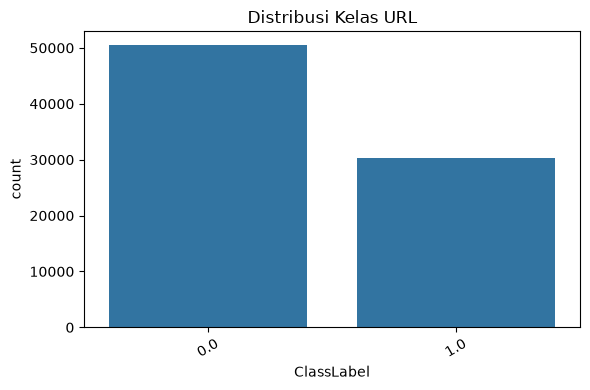

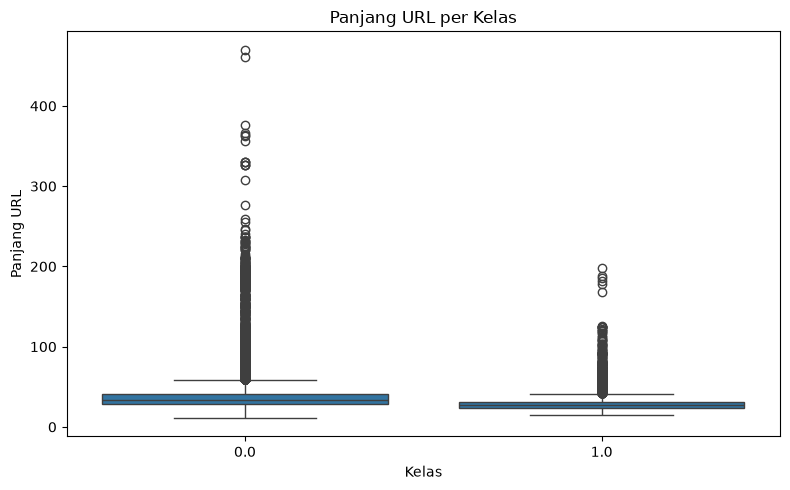


Rata-rata fitur URL per kelas:
            url_length  num_dots  num_hyphen  has_at  has_ip  has_https
ClassLabel                                                             
0.0             39.329     3.476       0.101     0.0   0.751      0.076
1.0             27.900     2.234       0.104     0.0   0.043      0.954


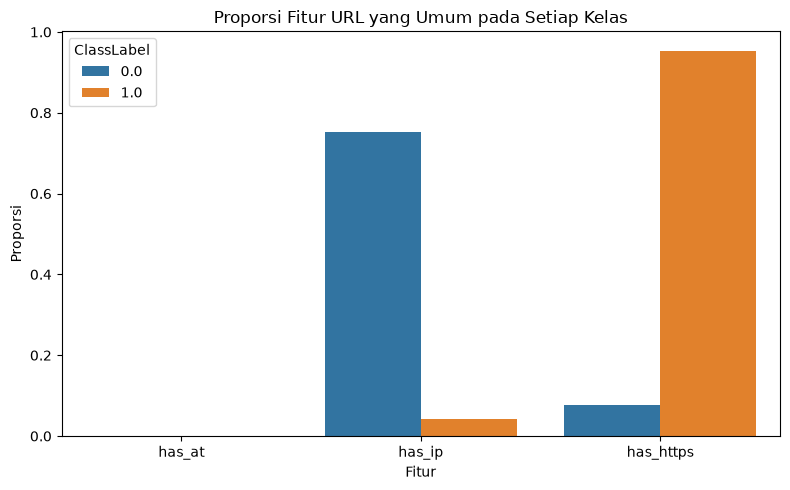

In [9]:
# EDA: karakteristik URL phishing vs aman

df['url_length'] = df['URL'].str.len()
df['num_dots'] = df['URL'].str.count(r'\.')
df['num_hyphen'] = df['URL'].str.count(r'-')
df['has_at'] = df['URL'].str.contains('@', case=False)
df['has_ip'] = df['URL'].str.contains(r':\/\/\d+\.\d+\.\d+\.\d+', case=False, regex=True)
df['has_https'] = df['URL'].str.lower().str.startswith('https')

print('Distribusi label:')
print(df['ClassLabel'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='ClassLabel')
plt.title('Distribusi Kelas URL')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='ClassLabel', y='url_length')
plt.title('Panjang URL per Kelas')
plt.ylabel('Panjang URL')
plt.xlabel('Kelas')
plt.tight_layout()
plt.show()

eda_summary = df.groupby('ClassLabel')[['url_length', 'num_dots', 'num_hyphen', 'has_at', 'has_ip', 'has_https']].mean().round(3)
print('\nRata-rata fitur URL per kelas:')
print(eda_summary)

# visualisasi ringkas fitur boolean
feature_cols = ['has_at', 'has_ip', 'has_https']
plot_df = df.groupby('ClassLabel')[feature_cols].mean().reset_index()
plot_df = plot_df.melt(id_vars='ClassLabel', var_name='feature', value_name='ratio')

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='feature', y='ratio', hue='ClassLabel')
plt.title('Proporsi Fitur URL yang Umum pada Setiap Kelas')
plt.ylabel('Proporsi')
plt.xlabel('Fitur')
plt.tight_layout()
plt.show()


# B Modelling

Setelah fitur URL diekstraksi dan diproses menjadi representasi numerik, langkah selanjutnya adalah membandingkan beberapa model klasifikasi. Tujuan utama dari eksperimen ini adalah mengevaluasi model yang paling mampu membedakan URL phishing dan URL aman.

Model yang dibandingkan:
1. Logistic Regression
2. Deep Learning 1 (Dense MLP)

3. Deep Learning 2 (Alternative MLP)Pemilihan model dilakukan dengan mempertimbangkan trade-off antara kecepatan, kemudahan interpretasi, dan kemampuan menangkap pola non-linear pada struktur URL. Logistic Regression berfungsi sebagai baseline, sedangkan model deep learning digunakan untuk mengecek apakah pola kompleks pada embedding URL dapat ditangkap dengan lebih baik.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2242.86it/s]


⚙️ Encoding URL...
⚙️ Encoding URL...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7259.87it/s]


⚙️ Encoding URL...


c:\Users\Alvin\miniconda3\envs\dl_env\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


⚙️ Encoding URL...
                 Model  Accuracy  Precision  Recall      F1
0  Logistic Regression    0.9650     0.9544  0.9523  0.9534
1      Deep Learning 1    0.9677     0.9638  0.9497  0.9567
2      Deep Learning 2    0.9679     0.9634  0.9507  0.9570


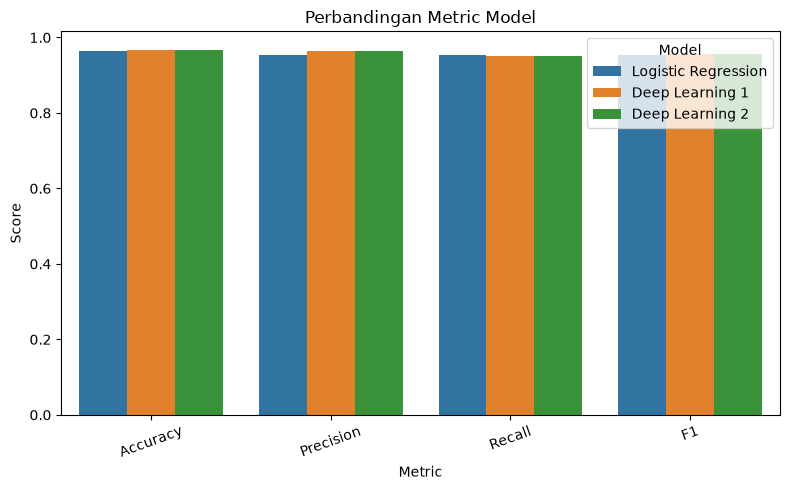

In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class KerasDLClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=20, batch_size=32):
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None
        self.model_ = None

    def build_model(self):
        model = Sequential([
            Dense(128, activation='relu', input_shape=(384,)),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def fit(self, x, y):
        x = np.asarray(x, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        self.model_ = self.build_model()
        early_stop = EarlyStopping(monitor='loss', patience=3, verbose=0)

        self.model_.fit(x, y,
                       epochs=self.epochs,
                       batch_size=self.batch_size,
                       verbose=0,
                       callbacks=[early_stop])
        return self

    def predict(self, x):
        check_is_fitted(self, ["model_"])
        X = np.asarray(x, dtype=np.float32)
        return (self.model_.predict(X, verbose=0) > 0.5).astype("int32")

    def predict_proba(self, X):
        check_is_fitted(self, ["model_"])
        X = np.asarray(X, dtype=np.float32)
        return self.model_.predict(X, verbose=0)

    def __sklearn_is_fitted__(self):
        return hasattr(self, "model_") and self.model_ is not None

# ----- MODEL COMPARISON -----
# embedding URL terlebih dahulu
embedder = URLEmbeddingTransformer(model_name='all-MiniLM-L6-v2')
X_train_emb = embedder.fit_transform(x_train_list)
X_test_emb = embedder.transform(x_test_list)

# label encoding untuk kebutuhan model
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# model 1: logistic regression
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
logreg.fit(X_train_emb, y_train_enc)
y_pred_logreg = logreg.predict(X_test_emb)

# model 2: deep learning 1 (Dense MLP)
dl_pipeline = Pipeline([
    ('processor', URLEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('classifier', KerasDLClassifier(epochs=15, batch_size=32))
])
dl_pipeline.fit(x_train_list, y_train_enc)
y_pred_dl_1 = dl_pipeline.predict(x_test_list)

# model 3: deep learning 2 (alternative MLP)
model_dl_2 = Sequential([
    Dense(256, activation='relu', input_shape=(384,)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_dl_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_dl_2.fit(X_train_emb, y_train_enc, epochs=15, batch_size=32, verbose=0)
y_pred_dl_2 = (model_dl_2.predict(X_test_emb, verbose=0) > 0.5).astype('int32')

comparison = {
    'Model': ['Logistic Regression', 'Deep Learning 1', 'Deep Learning 2'],
    'Accuracy': [
        accuracy_score(y_test_enc, y_pred_logreg),
        accuracy_score(y_test_enc, y_pred_dl_1),
        accuracy_score(y_test_enc, y_pred_dl_2)
    ],
    'Precision': [
        precision_score(y_test_enc, y_pred_logreg, zero_division=0),
        precision_score(y_test_enc, y_pred_dl_1, zero_division=0),
        precision_score(y_test_enc, y_pred_dl_2, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test_enc, y_pred_logreg, zero_division=0),
        recall_score(y_test_enc, y_pred_dl_1, zero_division=0),
        recall_score(y_test_enc, y_pred_dl_2, zero_division=0)
    ],
    'F1': [
        f1_score(y_test_enc, y_pred_logreg, zero_division=0),
        f1_score(y_test_enc, y_pred_dl_1, zero_division=0),
        f1_score(y_test_enc, y_pred_dl_2, zero_division=0)
    ]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score'),
            x='Metric', y='Score', hue='Model')
plt.title('Perbandingan Metric Model')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [11]:
dl_pipeline = Pipeline([
    ('processor', URLEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('classifier', KerasDLClassifier(epochs=15, batch_size=32))
])

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

dl_pipeline.fit(x_train_list, y_train_enc)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10159.52it/s]


⚙️ Encoding URL...


c:\Users\Alvin\miniconda3\envs\dl_env\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,model_name,'all-MiniLM-L6-v2'
Name,Type,Value
model_,SentenceTransformer,SentenceTrans...embedding'}) )
,epochs,15
,batch_size,32
Name,Type,Value
model_,Sequential,"<Sequential n...2, built=True>"


# C. Evaluation



In [18]:
comparison_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.965018,0.954380,0.952334,0.953356
1,Deep Learning 1,0.967742,0.963843,0.949695,0.956717
2,Deep Learning 2,0.967928,0.963396,0.950684,0.956998


Selain itu, tampilan confusion matrix dan grafik perbandingan metrik membantu memberikan interpretasi yang lebih jelas terhadap performa setiap model sebelum model final disimpan dan digunakan untuk prediksi baru.

Tahap evaluasi bertujuan untuk menilai apakah model mampu memisahkan URL phishing dan aman dengan akurat pada data uji. Metrik utama yang digunakan adalah akurasi, precision, recall, F1-score, serta confusion matrix.

Dari hasil perbandingan antar model, model yang memiliki akurasi dan F1-score paling tinggi biasanya dipilih sebagai model final. Jika model deep learning menghasilkan recall yang lebih tinggi dibanding logistic regression, maka model tersebut lebih unggul untuk kasus deteksi phishing, karena kesalahan yang lebih sering terjadi adalah melewatkan URL phishing yang berbahaya.

- Accuracy menunjukkan seberapa banyak prediksi benar secara keseluruhan.

- Precision menunjukkan sejauh mana prediksi phishing yang dihasilkan benar-benar phishing.- Confusion matrix membantu melihat jenis kesalahan model, apakah model lebih sering salah positif atau salah negatif.

- Recall menunjukkan kemampuan model mendeteksi semua URL phishing yang sebenarnya.- F1-score merupakan keseimbangan antara precision dan recall.

⚙️ Encoding URL...
AKURASI FINAL: 0.9662 (96.62%)

 Classirication Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     10088
           1       0.96      0.95      0.95      6063

    accuracy                           0.97     16151
   macro avg       0.97      0.96      0.96     16151
weighted avg       0.97      0.97      0.97     16151



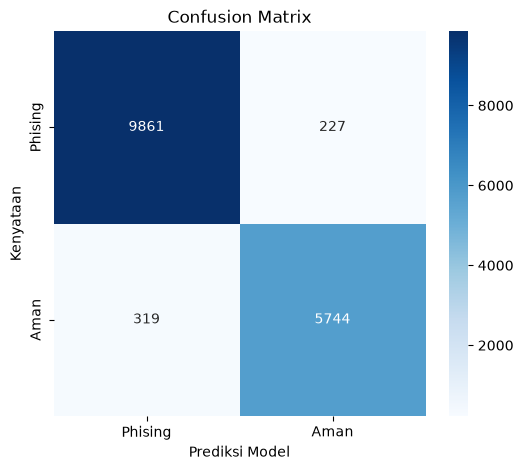

In [12]:
y_pred = dl_pipeline.predict(x_test_list)
acc = accuracy_score(y_test_enc, y_pred)
print(f"AKURASI FINAL: {acc:.4f} ({acc*100:.2f}%)")

print("\n Classirication Report:")
print(classification_report(y_test_enc, y_pred))

cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Phising', 'Aman'], yticklabels=['Phising', 'Aman'])
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan')
plt.title('Confusion Matrix')
plt.show()

In [13]:
y_prob = dl_pipeline.predict_proba(x_test_list)
auc_score = roc_auc_score(y_test_enc, y_prob)
print(auc_score)



⚙️ Encoding URL...


0.9754803449584281


In [14]:
dl_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,model_name,'all-MiniLM-L6-v2'
Name,Type,Value
model_,SentenceTransformer,SentenceTrans...embedding'}) )
,epochs,15
,batch_size,32
Name,Type,Value
model_,Sequential,"<Sequential n...2, built=True>"


In [15]:
classifier = dl_pipeline.named_steps['classifier']
model = classifier.model_

if model is None:
    raise ValueError("Model masih None. Pastikan pipeline.fit() berhasil dijalankan.")

save_dir = '../models'
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, 'phishing_detection_deeplearning.h5')
model.save(save_path)

print(f"Model berhasil disimpan: {save_path}")

Model berhasil disimpan: ../models\phishing_detection_deeplearning.h5


# D. Model Load

In [16]:
from tensorflow.keras.models import load_model
from pathlib import Path

ROOT_DIR = Path(os.getcwd()).parent.parent
sys.path.append(ROOT_DIR)
print(ROOT_DIR)

models_path = ROOT_DIR / 'backend' / 'models' / 'phishing_detection_deeplearning.h5'

model = load_model(
    models_path,
    custom_objects={"URLEmbeddingTransformer": URLEmbeddingTransformer}
)

embedder = URLEmbeddingTransformer(model_name="all-MiniLM-L6-v2")
embedder.fit([])  # supaya model_ siap dipakai



c:\Users\Alvin\Music\SE_final_project


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6632.07it/s]


,model_name,'all-MiniLM-L6-v2'
Name,Type,Value
model_,SentenceTransformer,SentenceTrans...embedding'}) )


In [17]:
def predict_url(url: str):
    # 1) ubah URL jadi embedding
    vec = embedder.transform(url)   # bentuk: array 1D atau 2D
    vec = np.asarray(vec).reshape(1, -1)

    # 2) prediksi
    prob = model.predict(vec, verbose=0)[0][0]
    label = "safe" if prob >= 0.5 else "phishing"

    return {
        "url": url,
        "probability": float(prob),
        "label": label
    }

# contoh pakai
print(predict_url("https://google.com"))

⚙️ Encoding URL...
{'url': 'https://google.com', 'probability': 0.9999617338180542, 'label': 'safe'}
